#     Rainfall Prediction using ML

---

## Step 1: Import Required Libraries

In this step, we import all the libraries needed for:



In [144]:
## Visualization and Data Handling Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Statistical and Time Series Libraries
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from pmdarima import auto_arima

## Scaling
from sklearn.preprocessing import MinMaxScaler

## Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
;
## Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Others
import math
import warnings
warnings.filterwarnings('ignore')


In [145]:
rainfall_df = pd.read_csv(r"C:\Users\karna\Downloads\rainfall_predection_vadodara\data\rainfalldf.csv")

In [146]:
rainfall_df


,INDEX,YEAR,MN,DT,MAX,MIN,AW,RF,EVP,DRNRF(hrs),...,T.1,G.1,DUR.1,T.2,G.2,DUR.2,T.3,G.3,DUR.3,Unnamed: 39
0,42744,1991,1,1,20.8,5.7,2,0.0,,0,...,,,,,,,,,,
1,42744,1991,1,2,20.2,5.7,3,0.0,,0,...,,,,,,,,,,
2,42744,1991,1,3,19.6,5.9,6,0.0,,0,...,,,,,,,,,,
3,42744,1991,1,4,21.1,7.1,6,0.0,,0,...,,,,,,,,,,
4,42744,1991,1,5,23.6,9.1,3,0.0,,0,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9303,42744,2021,11,26,30.9,17.6,,0.0,,,...,,,,,,,,,,
9304,42744,2021,11,27,32.0,18.5,,0.0,,,...,,,,,,,,,,
9305,42744,2021,11,28,32.0,18.3,,0.0,,,...,,,,,,,,,,
9306,42744,2021,11,29,31.6,18.0,,0.0,,,...,,,,,,,,,,


#   Replacing blank values with the NAN

In [4]:
rainfalldata = rainfall_df.replace(r'^\s*$', float('NaN'), regex=True)


In [5]:
rainfalldata.head()


,INDEX,YEAR,MN,DT,MAX,MIN,AW,RF,EVP,DRNRF(hrs),...,T.1,G.1,DUR.1,T.2,G.2,DUR.2,T.3,G.3,DUR.3,Unnamed: 39
0,42744,1991,1,1,20.8,5.7,2,0.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,42744,1991,1,2,20.2,5.7,3,0.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,42744,1991,1,3,19.6,5.9,6,0.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,42744,1991,1,4,21.1,7.1,6,0.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,42744,1991,1,5,23.6,9.1,3,0.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
rainfalldata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9308 entries, 0 to 9307
Data columns (total 40 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   INDEX        9308 non-null   int64  
 1   YEAR         9308 non-null   int64  
 2   MN           9308 non-null   int64  
 3   DT           9308 non-null   int64  
 4   MAX          8958 non-null   float64
 5   MIN          8215 non-null   float64
 6   AW           3528 non-null   object 
 7   RF           8901 non-null   float64
 8   EVP          0 non-null      float64
 9   DRNRF(hrs)   6521 non-null   object 
 10  DRNRF(mnts)  6521 non-null   object 
 11  SSH          1 non-null      object 
 12  TS           0 non-null      float64
 13  N            0 non-null      float64
 14  FFF          0 non-null      float64
 15  D            0 non-null      float64
 16  TOCSQ        0 non-null      float64
 17  DU           0 non-null      float64
 18  RA           9063 non-null   object 
 19  DZ    

In [7]:
rainfalldata.isna().sum()


INDEX             0
YEAR              0
MN                0
DT                0
MAX             350
MIN            1093
AW             5780
RF              407
EVP            9308
DRNRF(hrs)     2787
DRNRF(mnts)    2787
SSH            9307
TS             9308
N              9308
FFF            9308
D              9308
TOCSQ          9308
DU             9308
RA              245
DZ              245
SN              245
SL              245
HA              245
TH              245
DS              245
FG              245
GA              245
T              9308
G              9308
DUR            9308
T.1            9308
G.1            9308
DUR.1          9308
T.2            9308
G.2            9308
DUR.2          9308
T.3            9308
G.3            9308
DUR.3          9308
Unnamed: 39    9308
dtype: int64

##Dropping the columns which are higher missing values

In [8]:

rainfalldata.drop(['INDEX','EVP','SSH','TS','N','FFF','D','TOCSQ','DU','T','G','DUR','T.1','G.1','DUR.1','T.2','G.2','DUR.2','T.3','G.3','DUR.3','Unnamed: 39'],
                  axis=1, inplace=True)


In [9]:
rainfalldata


,YEAR,MN,DT,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
0,1991,1,1,20.8,5.7,2,0.0,0,0,0,0,0,0,0,0,0,0,0
1,1991,1,2,20.2,5.7,3,0.0,0,0,0,0,0,0,0,0,0,0,0
2,1991,1,3,19.6,5.9,6,0.0,0,0,0,0,0,0,0,0,0,0,0
3,1991,1,4,21.1,7.1,6,0.0,0,0,0,0,0,0,0,0,0,0,0
4,1991,1,5,23.6,9.1,3,0.0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9303,2021,11,26,30.9,17.6,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0
9304,2021,11,27,32.0,18.5,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0
9305,2021,11,28,32.0,18.3,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0
9306,2021,11,29,31.6,18.0,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0


In [10]:
raindf = rainfalldata.iloc[:8241]


In [11]:
rainfalldata


,YEAR,MN,DT,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
0,1991,1,1,20.8,5.7,2,0.0,0,0,0,0,0,0,0,0,0,0,0
1,1991,1,2,20.2,5.7,3,0.0,0,0,0,0,0,0,0,0,0,0,0
2,1991,1,3,19.6,5.9,6,0.0,0,0,0,0,0,0,0,0,0,0,0
3,1991,1,4,21.1,7.1,6,0.0,0,0,0,0,0,0,0,0,0,0,0
4,1991,1,5,23.6,9.1,3,0.0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9303,2021,11,26,30.9,17.6,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0
9304,2021,11,27,32.0,18.5,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0
9305,2021,11,28,32.0,18.3,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0
9306,2021,11,29,31.6,18.0,NaN,0.0,NaN,NaN,0,0,0,0,0,0,0,0,0


In [12]:
raindf = rainfalldata.iloc[:8241].copy()


#   Convert the month,day,year column in Date format

In [13]:
raindf['Date'] = pd.to_datetime(
    raindf['YEAR'].astype(str) + '-' + raindf['MN'].astype(str) + '-' + raindf['DT'].astype(str),
    yearfirst=True
)


In [14]:
raindf.drop(['YEAR','MN','DT'], axis=1, inplace=True)


In [15]:
first_column = raindf.pop('Date')


In [16]:
raindf.insert(0, 'Date', first_column)


In [17]:
raindf.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8241 entries, 0 to 8240
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         8241 non-null   datetime64[ns]
 1   MAX          7891 non-null   float64       
 2   MIN          7148 non-null   float64       
 3   AW           3528 non-null   object        
 4   RF           7834 non-null   float64       
 5   DRNRF(hrs)   6521 non-null   object        
 6   DRNRF(mnts)  6521 non-null   object        
 7   RA           7996 non-null   object        
 8   DZ           7996 non-null   object        
 9   SN           7996 non-null   object        
 10  SL           7996 non-null   object        
 11  HA           7996 non-null   object        
 12  TH           7996 non-null   object        
 13  DS           7996 non-null   object        
 14  FG           7996 non-null   object        
 15  GA           7996 non-null   object        
dtypes: dat

#Filling missing values using interpolation method

In [18]:
raindf['MAX'] = raindf['MAX'].interpolate(method = 'linear')
raindf['MIN'] = raindf['MIN'].interpolate(method = 'linear')
raindf['AW'] = raindf['AW'].interpolate(method = 'linear').astype('float64')
raindf['RF'] = raindf['RF'].interpolate(method = 'linear')
raindf['DRNRF(hrs)'] = raindf['DRNRF(hrs)'].interpolate(method = 'linear').astype('float64')
raindf['DRNRF(mnts)'] = raindf['DRNRF(mnts)'].interpolate(method = 'linear').astype('float64')

#   Checking missing values

In [19]:
raindf.isna().sum()


Date              0
MAX               0
MIN               0
AW             4713
RF                0
DRNRF(hrs)     1720
DRNRF(mnts)    1720
RA              245
DZ              245
SN              245
SL              245
HA              245
TH              245
DS              245
FG              245
GA              245
dtype: int64

#   Convert the daily rainfall data into monthly

In [20]:

# Ensure Date is in datetime format
raindf['Date'] = pd.to_datetime(raindf['Date'], errors='coerce')

# Replace all-zero strings or placeholder text with NaN
raindf = raindf.replace(r'^[0]+$', np.nan, regex=True)

# Convert object (text) columns to numeric where possible
for col in raindf.select_dtypes(include='object').columns:
    if col != 'Date':
        raindf[col] = pd.to_numeric(raindf[col], errors='coerce')
monthly_df = raindf.set_index('Date').select_dtypes(include=[np.number]).resample('M').mean()

# Fill NaN values with column means
df_month = monthly_df.fillna(monthly_df.mean())

# Reset index to restore 'Date' as a column
monthly_df = df_month.reset_index()

# Quick check
print("✅ Monthly data created successfully!")
display(monthly_df.head())


✅ Monthly data created successfully!


,Date,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
0,1991-01-31,26.477419,11.209677,3.548387,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-28,30.221429,14.492857,2.714286,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03-31,35.190323,18.651613,2.677419,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04-30,37.896667,22.790000,3.700000,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05-31,38.883871,25.761290,4.935484,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
monthly_df.isna().sum()


Date             0
MAX              0
MIN              0
AW               0
RF               0
DRNRF(hrs)       0
DRNRF(mnts)      0
RA               0
DZ               0
SN             276
SL             276
HA             276
TH             276
DS             276
FG             276
GA             276
dtype: int64

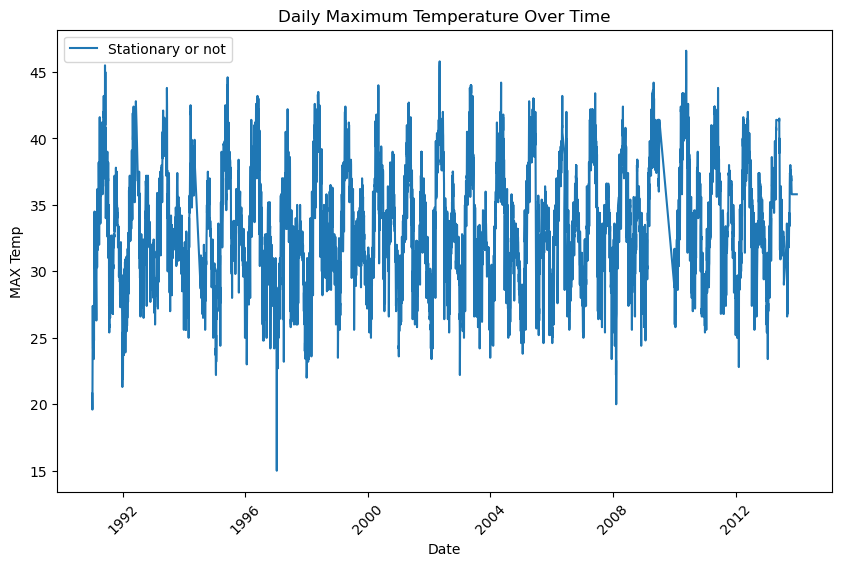

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='MAX', data=raindf, label='Stationary or not')

plt.xlabel('Date')
plt.ylabel('MAX Temp')
plt.title('Daily Maximum Temperature Over Time')
plt.xticks(rotation=45)  # rotate date labels for readability
plt.legend()
plt.show()


#   Fitting a model on first non-missing dataset

In [23]:
df = raindf.iloc[:8241, :5]


In [24]:
df

,Date,MAX,MIN,AW,RF
0,1991-01-01,20.8,5.7,2.0,0.0
1,1991-01-02,20.2,5.7,3.0,0.0
2,1991-01-03,19.6,5.9,6.0,0.0
3,1991-01-04,21.1,7.1,6.0,0.0
4,1991-01-05,23.6,9.1,3.0,0.0
...,...,...,...,...,...
8236,2013-12-27,35.8,20.6,NaN,0.0
8237,2013-12-28,35.8,20.6,NaN,0.0
8238,2013-12-29,35.8,20.6,NaN,0.0
8239,2013-12-30,35.8,20.6,NaN,0.0


#   To Check Time Series is stationary or not

In [25]:
df.index = pd.to_datetime(df.Date)


In [26]:
df_month


,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
Date,,,,,,,,,,,,,,,
1991-01-31,26.477419,11.209677,3.548387,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-02-28,30.221429,14.492857,2.714286,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-03-31,35.190323,18.651613,2.677419,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-04-30,37.896667,22.790000,3.700000,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-05-31,38.883871,25.761290,4.935484,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-08-31,33.467244,20.444150,3.282338,2.315404,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-09-30,31.379310,25.017241,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-31,36.416129,23.070968,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:

df.drop(['Date'], axis=1)


,MAX,MIN,AW,RF
Date,,,,
1991-01-01,20.8,5.7,2.0,0.0
1991-01-02,20.2,5.7,3.0,0.0
1991-01-03,19.6,5.9,6.0,0.0
1991-01-04,21.1,7.1,6.0,0.0
1991-01-05,23.6,9.1,3.0,0.0
...,...,...,...,...
2013-12-27,35.8,20.6,NaN,0.0
2013-12-28,35.8,20.6,NaN,0.0
2013-12-29,35.8,20.6,NaN,0.0


In [28]:
adftest = adfuller(df['RF'])
print('ADF Statistics: %f'%adftest[0])
print('P-value: %f'%adftest[1])


ADF Statistics: -13.679008
P-value: 0.000000


In [29]:
adftest2 = adfuller(df['MAX'])
print('ADF Statistics: %f'%adftest2[0])
print('P-value: %f'%adftest2[1])


ADF Statistics: -9.433468
P-value: 0.000000


In [30]:
monthly_df.index = pd.to_datetime(monthly_df.Date)


In [31]:
df1 = monthly_df['Date'].index
df1 = monthly_df['RF']

In [32]:
df2 = pd.DataFrame(df1)
df2

,RF
Date,
1991-01-31,0.000000
1991-02-28,0.000000
1991-03-31,0.000000
1991-04-30,0.000000
1991-05-31,0.000000
...,...
2013-08-31,2.315404
2013-09-30,0.000000
2013-10-31,0.000000


#   Plots of Seasonal ACF and PACF

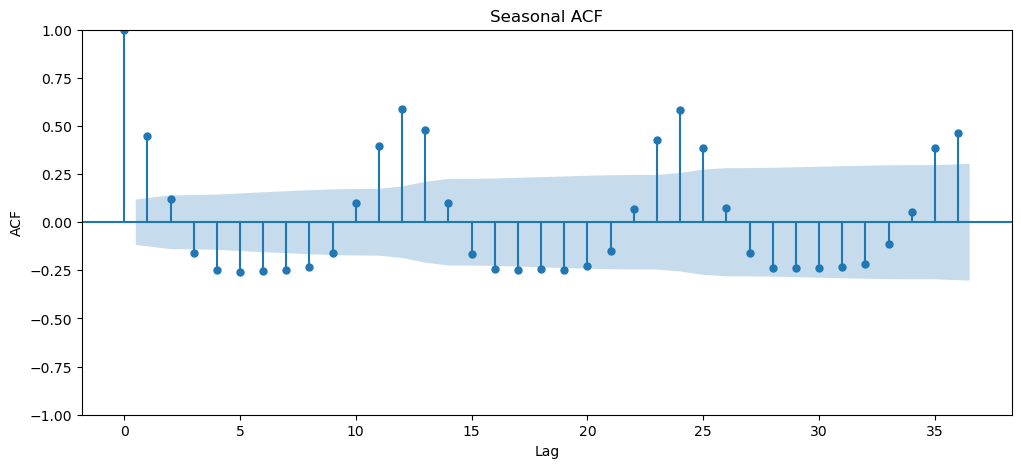

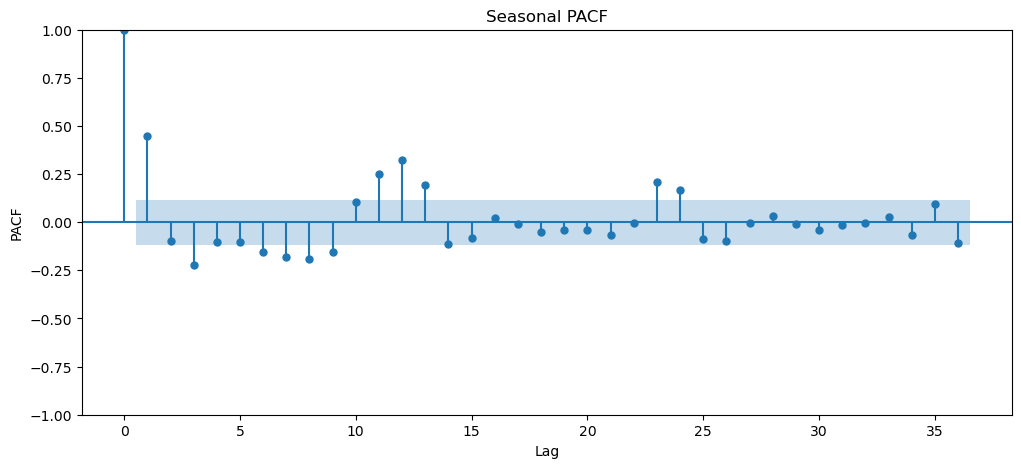

In [33]:
# Plot the seasonal ACF
fig, ax = plt.subplots(figsize=(12,5))
sm.graphics.tsa.plot_acf(df2, lags=12*3, ax=ax)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('Seasonal ACF')

# Plot the seasonal PACF
fig, ax = plt.subplots(figsize=(12,5))
sm.graphics.tsa.plot_pacf(df2, lags=12*3, ax=ax)
ax.set_xlabel('Lag')
ax.set_ylabel('PACF')
ax.set_title('Seasonal PACF')

plt.show()

#   Splitting the datas set into Training and Testing

In [34]:
## Training and Testing Dataset 
train_size = int(len(df2) * 0.7)  
train = df2[:train_size]
test = df2[train_size:] 

#   1)Fitting seasonal ARIMA model on train Dataset

In [35]:
# Define the seasonal ARIMA model
model12 = sm.tsa.SARIMAX(train, order=(2, 0, 2), seasonal_order=(2, 0, 2, 12))

# Fit the model
results2 = model12.fit()

# Print the summary of the model
print(results2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                 RF   No. Observations:                  193
Model:             SARIMAX(2, 0, 2)x(2, 0, 2, 12)   Log Likelihood                -505.443
Date:                            Wed, 29 Apr 2026   AIC                           1028.886
Time:                                    09:09:15   BIC                           1058.250
Sample:                                01-31-1991   HQIC                          1040.778
                                     - 01-31-2007                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1486      0.612      0.243      0.808      -1.052       1.349
ar.L2         -0.1057      0.862   

In [36]:
# Make a forecast for the next 30 days
forecast2 = results2.forecast(steps=120)
forecast2 = forecast2.clip(lower=0)

In [37]:
forecast2


2007-02-28    0.386704
2007-03-31    0.000000
2007-04-30    0.000000
2007-05-31    0.125466
2007-06-30    8.307940
                ...   
2016-09-30    3.373667
2016-10-31    0.284159
2016-11-30    0.009427
2016-12-31    0.013635
2017-01-31    0.013799
Freq: ME, Name: predicted_mean, Length: 120, dtype: float64

In [38]:
# Make predictions using the fitted model on the test set
predictions = results2.predict(start=len(train), end=len(df2)-1)
predictions.clip(lower=0)


2007-02-28    0.386704
2007-03-31    0.000000
2007-04-30    0.000000
2007-05-31    0.125466
2007-06-30    8.307940
                ...   
2013-08-31    8.206707
2013-09-30    4.061535
2013-10-31    0.323396
2013-11-30    0.007649
2013-12-31    0.013618
Freq: ME, Name: predicted_mean, Length: 83, dtype: float64

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [40]:
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

# Print the results
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)

MAE:  1.6604963638715327
MSE:  10.390735889025242
RMSE:  3.223466439878852


#   Forecasted Plot on Training dataset ( SARIMA)

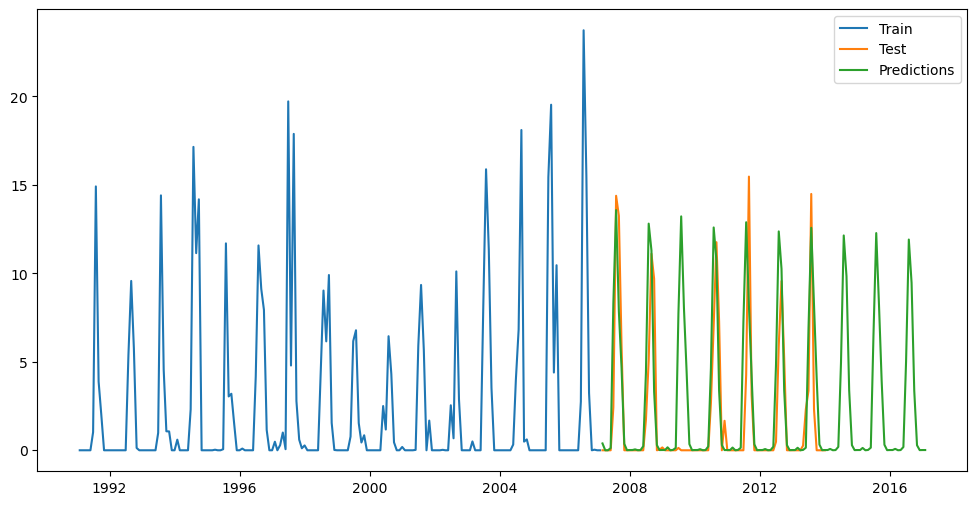

In [41]:
fig, ax = plt.subplots(figsize=(12, 6))   # Creates a figure with a plotting area

ax.plot(train.index, train.values, label='Train')   # Plots training data
ax.plot(test.index, test.values, label='Test')      # Plots test (actual) data
ax.plot(forecast2.index, forecast2.values, label='Predictions')  # Plots model’s forecast

ax.legend()   # Adds a legend to distinguish lines
plt.show()    # Displays the plot


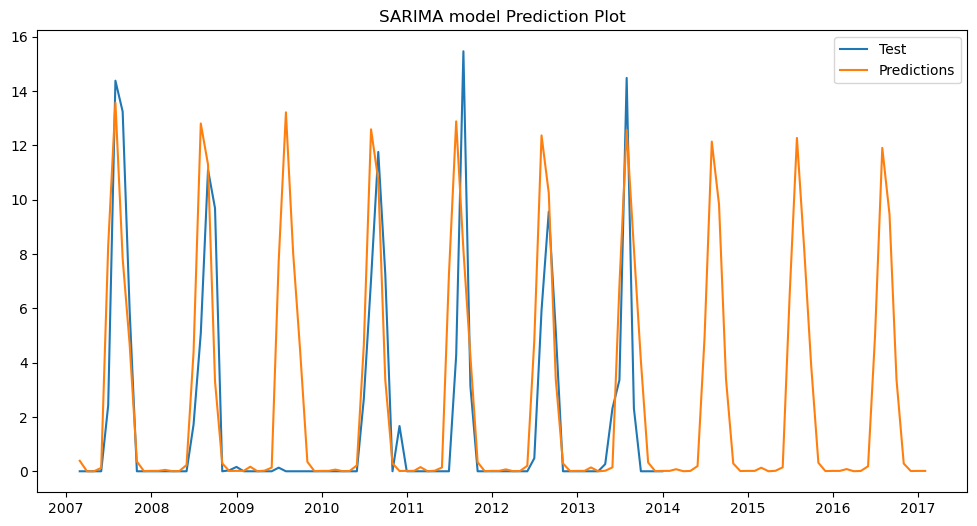

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(test.index, test.values, label='Test')
ax.plot(forecast2.index, forecast2.values, label='Predictions')
ax.set_title('SARIMA model Prediction Plot')
ax.legend()
plt.show()

#   2) Fitting Auto Seasonal ARIMA model

In [43]:
# Create a pandas Series with the rainfall data
rainfall = pd.Series(monthly_df['RF'])

# Split the data into training and testing sets
train_size = int(len(rainfall) * 0.7)  # 70% for training
train_data = rainfall[:train_size]
test_data = rainfall[train_size:]

# Fit the auto seasonal ARIMA model
from pmdarima import auto_arima
autosarima_model = auto_arima(train_data, seasonal=True, m=12)

# Print the model summary
print(autosarima_model.summary())


                                   SARIMAX Results                                   
Dep. Variable:                             y   No. Observations:                  193
Model:             SARIMAX(2, 0, [1, 2], 12)   Log Likelihood                -507.958
Date:                       Wed, 29 Apr 2026   AIC                           1027.916
Time:                               09:09:50   BIC                           1047.492
Sample:                           01-31-1991   HQIC                          1035.843
                                - 01-31-2007                                         
Covariance Type:                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0391      0.069      0.566      0.572      -0.096       0.175
ar.S.L12       0.1559      0.194      0.804      0.421      -0.224       0.

In [44]:
# Make forecasts for the next 12 months
forecasted = autosarima_model.predict(n_periods=120)
forecasted

2007-02-28    0.216372
2007-03-31    0.161923
2007-04-30    0.189705
2007-05-31    0.321944
2007-06-30    7.258080
                ...   
2016-09-30    3.818412
2016-10-31    0.675788
2016-11-30    0.324321
2016-12-31    0.333075
2017-01-31    0.338202
Freq: ME, Length: 120, dtype: float64

In [45]:
ASpredictions = autosarima_model.predict(start=len(train_data), end=len(df2)-1)
ASpredictions.clip(lower=0)


2007-02-28     0.216372
2007-03-31     0.161923
2007-04-30     0.189705
2007-05-31     0.321944
2007-06-30     7.258080
2007-07-31    12.402337
2007-08-31     8.076024
2007-09-30     4.507131
2007-10-31     0.568275
2007-11-30     0.155065
Freq: ME, dtype: float64

In [46]:
test_data2 = test_data[:'2007-11-30']


In [47]:
# Calculate the MAE, MSE, and RMSE
mae = mean_absolute_error(test_data2, ASpredictions)
mse = mean_squared_error(test_data2, ASpredictions)
rmse = np.sqrt(mse)

# Print the results
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)


MAE:  1.4995011574716774
MSE:  5.650392863930529
RMSE:  2.377055502913327


#   Prediction Plot of Training and Testing Datasset (Auto SARIMA)

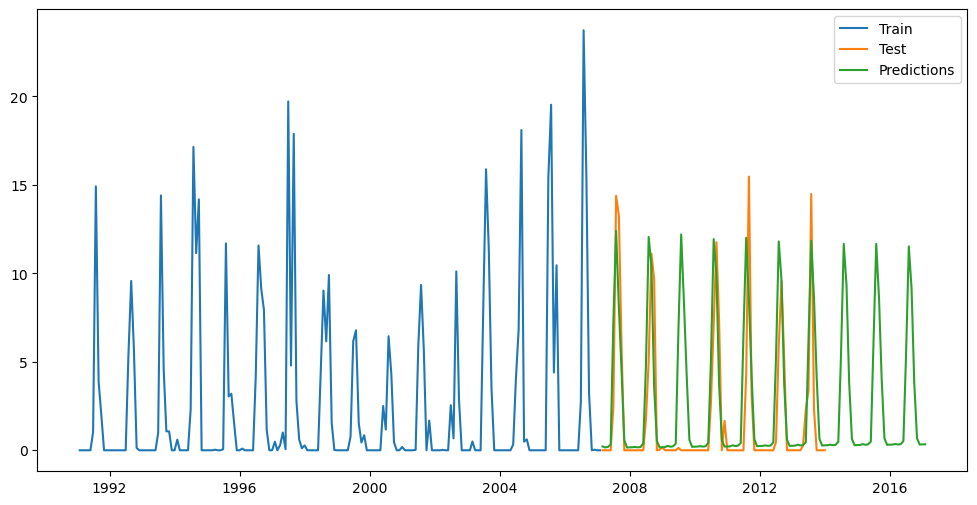

In [48]:
# Plot the actual and predicted values

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train.index, train.values, label='Train')
ax.plot(test.index, test.values, label='Test')
ax.plot(forecasted.index, forecasted.values, label='Predictions')
ax.legend()
plt.show()

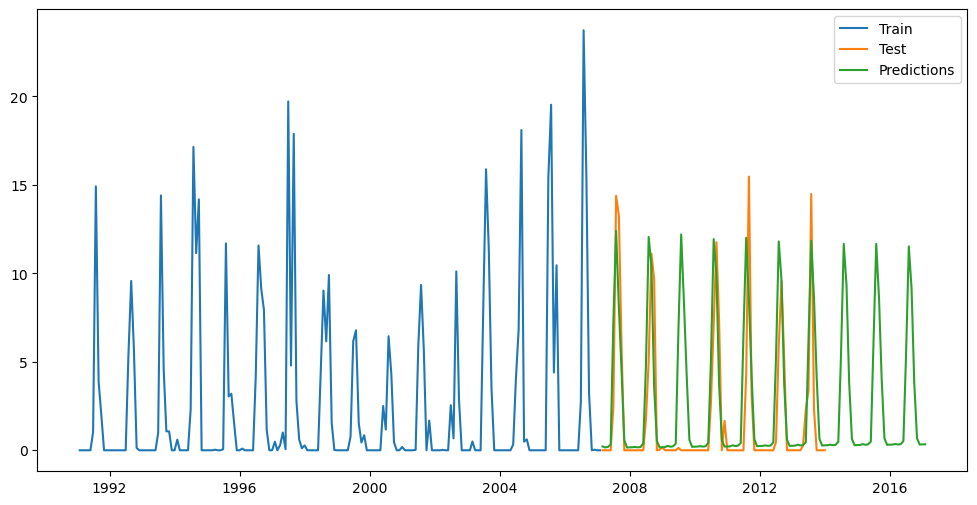

In [49]:
# Plot the actual and predicted values

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train.index, train.values, label='Train')
ax.plot(test.index, test.values, label='Test')
ax.plot(forecasted.index, forecasted.values, label='Predictions')
ax.legend()
plt.show()

In [50]:
# Make predictions on the test data
forecast = autosarima_model.predict(n_periods=len(test_data))

# Calculate the RMSE
rmse = np.sqrt(np.mean((forecast - test_data)**2))

# Print the RMSE
print('RMSE:', rmse)

RMSE: 3.0488939676039783


#   ACF and PACF Plots to check the parameters p,d,q

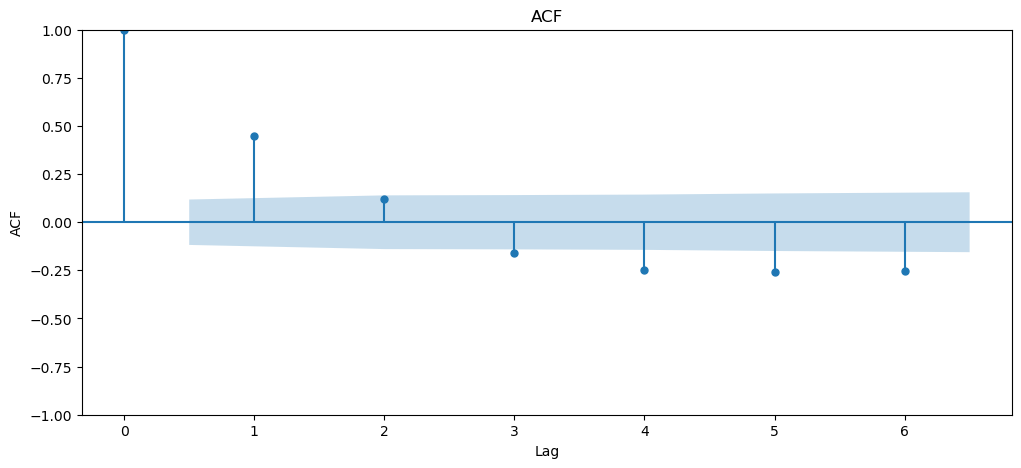

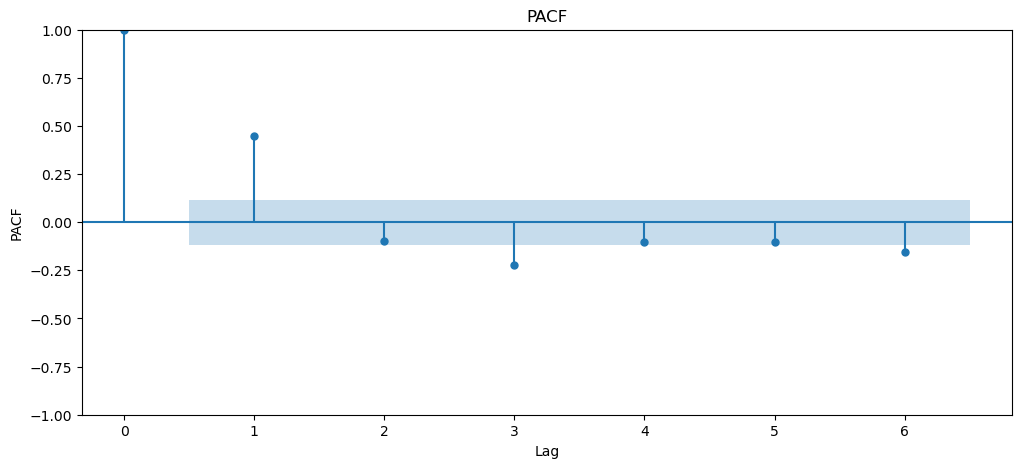

In [51]:
# Plot the seasonal ACF
fig, ax = plt.subplots(figsize=(12,5))
sm.graphics.tsa.plot_acf(df2, lags=6, ax=ax)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('ACF')

# Plot the seasonal PACF
fig, ax = plt.subplots(figsize=(12,5))
sm.graphics.tsa.plot_pacf(df2, lags=6, ax=ax)
ax.set_xlabel('Lag')
ax.set_ylabel('PACF')
ax.set_title('PACF')

plt.show()

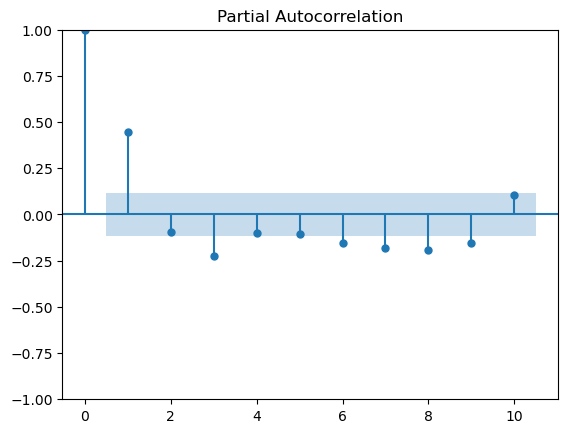

In [52]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Now you can plot PACF
plot_pacf(df1, lags=10)
plt.show()


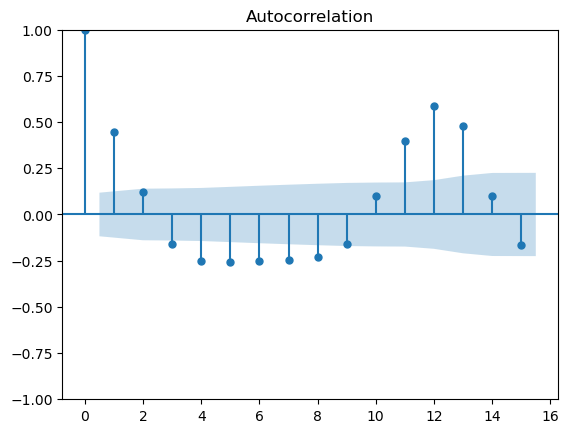

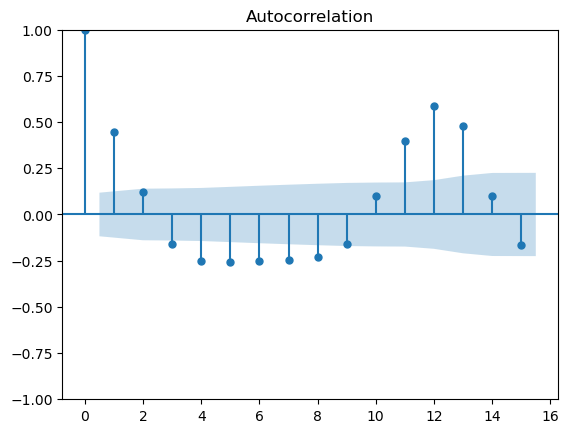

In [53]:
plot_acf(df1,lags = 15)

# q value is 0

#   3)Fitting auto ARIMA model

In [54]:
# Create a pandas Series with the rainfall data
rainfall = pd.Series(df_month['RF'])

# Split the data into training and testing sets
train_size = int(len(rainfall) * 0.7) # 70% for training
train_data = rainfall[:train_size]
test_data = rainfall[train_size:]

# Use the auto_arima function to fit an ARIMA model to the training data
autoarima_model = auto_arima(train_data, seasonal=False, m=12)

# Print the model summary
print(autoarima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  193
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -555.801
Date:                Wed, 29 Apr 2026   AIC                           1117.602
Time:                        09:09:54   BIC                           1127.390
Sample:                    01-31-1991   HQIC                          1121.566
                         - 01-31-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.4254      0.819      1.740      0.082      -0.180       3.031
ar.L1          0.4202      0.070      6.044      0.000       0.284       0.556
sigma2        18.5544      1.957      9.481      0.0

In [55]:
# Make predictions using the fitted model on the test set
Apredictions = autoarima_model.predict(start=len(train_data), end=len(df2)-1)
Apredictions.clip(lower=0)

2007-02-28    1.425439
2007-03-31    2.024341
2007-04-30    2.275971
2007-05-31    2.381693
2007-06-30    2.426113
2007-07-31    2.444776
2007-08-31    2.452617
2007-09-30    2.455912
2007-10-31    2.457296
2007-11-30    2.457878
Freq: ME, dtype: float64

In [56]:

test_data2

Date
2007-02-28     0.000000
2007-03-31     0.000000
2007-04-30     0.000000
2007-05-31     0.000000
2007-06-30     2.426667
2007-07-31    14.380645
2007-08-31    13.245161
2007-09-30     5.910000
2007-10-31     0.000000
2007-11-30     0.000000
Name: RF, dtype: float64

In [57]:
test_data2 = test_data[:'2007-11-30']

In [58]:
# Make predictions using the fitted model on the test set
predictions4 = autoarima_model.predict(start=len(train_data), end=len(df2)-1)

# Calculate the MAE, MSE, and RMSE on the test set
mae = mean_absolute_error(test_data2, Apredictions)
mse = mean_squared_error(test_data2, Apredictions)
rmse = np.sqrt(mse)

# Print the results
print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)

MAE:  3.9205672312390405
MSE:  29.993650203945407
RMSE:  5.476645889953577


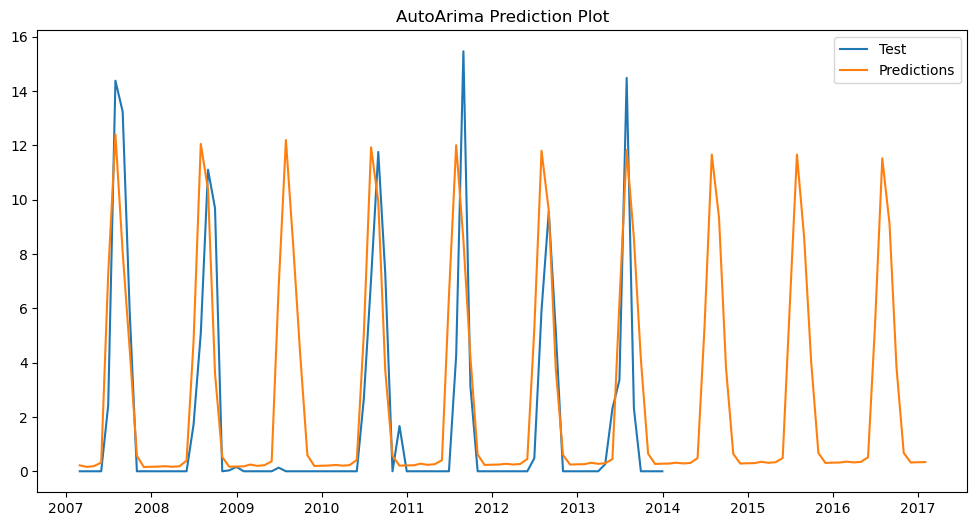

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(test.index, test.values, label='Test')
ax.plot(forecasted.index, forecasted.values, label='Predictions')
ax.set_title('AutoArima Prediction Plot')
ax.legend()
plt.show()

#   Fitting ARIMA Model

In [60]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Use the same df2 you used earlier (must have a DatetimeIndex)
# And same train/test as other models
train_data = df2.iloc[:int(len(df2)*0.7)]
test_data  = df2.iloc[int(len(df2)*0.7):]

# Fit ARIMA — using your chosen order
arima_model = sm.tsa.arima.ARIMA(train_data, order=(2,0,0))
arima_result = arima_model.fit()

print(arima_result.summary())


                               SARIMAX Results                                
Dep. Variable:                     RF   No. Observations:                  193
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -555.616
Date:                Wed, 29 Apr 2026   AIC                           1119.232
Time:                        09:09:56   BIC                           1132.283
Sample:                    01-31-1991   HQIC                          1124.517
                         - 01-31-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4619      1.167      2.109      0.035       0.174       4.750
ar.L1          0.4385      0.073      6.036      0.000       0.296       0.581
ar.L2         -0.0436      0.053     -0.829      0.4

In [61]:
# Predict exactly for test period (aligned with dates)
pred_test = arima_result.get_prediction(
    start=test_data.index[0],
    end=test_data.index[-1],
    dynamic=False
)

pred_series = pred_test.predicted_mean
pred_series = pred_series.clip(lower=0)   # rainfall can't be negative

# Confidence intervals (optional)
pred_ci = pred_test.conf_int()


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test_data, pred_series)
mse = mean_squared_error(test_data, pred_series)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)


MAE : 3.0396538639903348
MSE : 15.379874217303438
RMSE: 3.9217182735764484


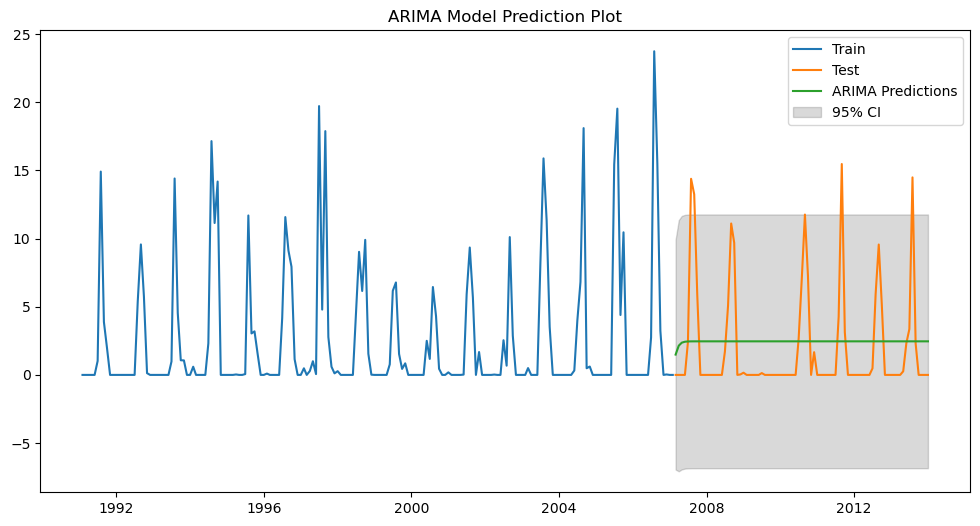

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train_data.index, train_data, label='Train')
plt.plot(test_data.index, test_data, label='Test')
plt.plot(pred_series.index, pred_series, label='ARIMA Predictions')

# Optional confidence interval shading
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:,0],
                 pred_ci.iloc[:,1],
                 color='k', alpha=0.15, label='95% CI')

plt.title('ARIMA Model Prediction Plot')
plt.legend()
plt.show()


#   Installing Keras and tensorflow for LSTM and GRU Model


In [64]:
pip install keras


Note: you may need to restart the kernel to use updated packages.


In [65]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [66]:
df



,Date,MAX,MIN,AW,RF
Date,,,,,
1991-01-01,1991-01-01,20.8,5.7,2.0,0.0
1991-01-02,1991-01-02,20.2,5.7,3.0,0.0
1991-01-03,1991-01-03,19.6,5.9,6.0,0.0
1991-01-04,1991-01-04,21.1,7.1,6.0,0.0
1991-01-05,1991-01-05,23.6,9.1,3.0,0.0
...,...,...,...,...,...
2013-12-27,2013-12-27,35.8,20.6,NaN,0.0
2013-12-28,2013-12-28,35.8,20.6,NaN,0.0
2013-12-29,2013-12-29,35.8,20.6,NaN,0.0


#   Fitting LSTM Model

In [67]:
raindata = df_month.drop([])


In [68]:
raindata = monthly_df.drop(['Date'],axis=1)


In [69]:
raindata = monthly_df.set_index(['Date'])


In [70]:
raindata


,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
Date,,,,,,,,,,,,,,,
1991-01-31,26.477419,11.209677,3.548387,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-02-28,30.221429,14.492857,2.714286,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-03-31,35.190323,18.651613,2.677419,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-04-30,37.896667,22.790000,3.700000,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-05-31,38.883871,25.761290,4.935484,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-08-31,33.467244,20.444150,3.282338,2.315404,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-09-30,31.379310,25.017241,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-31,36.416129,23.070968,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
new_raindata = raindata.reset_index()


In [72]:
new_raindata


,Date,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
0,1991-01-31,26.477419,11.209677,3.548387,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-28,30.221429,14.492857,2.714286,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03-31,35.190323,18.651613,2.677419,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04-30,37.896667,22.790000,3.700000,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05-31,38.883871,25.761290,4.935484,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,2013-08-31,33.467244,20.444150,3.282338,2.315404,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
272,2013-09-30,31.379310,25.017241,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
273,2013-10-31,36.416129,23.070968,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
274,2013-11-30,35.800000,20.600000,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
rainfalldata = new_raindata.set_index(['Date'])


In [74]:
train_dates = pd.to_datetime(new_raindata['Date'])


In [75]:
train_dates


0     1991-01-31
1     1991-02-28
2     1991-03-31
3     1991-04-30
4     1991-05-31
         ...    
271   2013-08-31
272   2013-09-30
273   2013-10-31
274   2013-11-30
275   2013-12-31
Name: Date, Length: 276, dtype: datetime64[ns]

In [76]:
rainfalldata


,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
Date,,,,,,,,,,,,,,,
1991-01-31,26.477419,11.209677,3.548387,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-02-28,30.221429,14.492857,2.714286,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-03-31,35.190323,18.651613,2.677419,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-04-30,37.896667,22.790000,3.700000,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-05-31,38.883871,25.761290,4.935484,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-08-31,33.467244,20.444150,3.282338,2.315404,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-09-30,31.379310,25.017241,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-31,36.416129,23.070968,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
cols = list(rainfalldata)[3:4]


In [78]:
cols


['RF']

<Axes: >

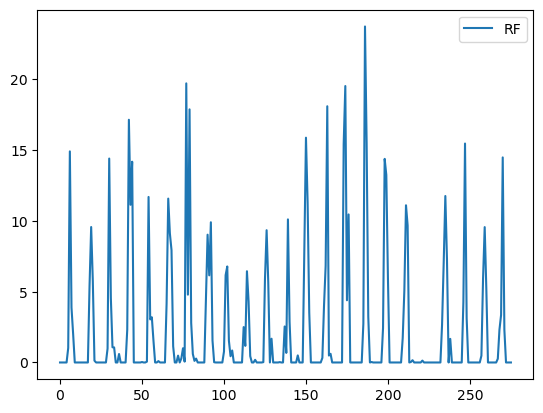

In [79]:
training_df = new_raindata[cols].astype(float)
plot_df = training_df
plot_df.plot.line()

In [80]:
training_df.isna().sum()


RF    0
dtype: int64

In [81]:
len(training_df)


276

In [82]:
new_raindata


,Date,MAX,MIN,AW,RF,DRNRF(hrs),DRNRF(mnts),RA,DZ,SN,SL,HA,TH,DS,FG,GA
0,1991-01-31,26.477419,11.209677,3.548387,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1991-02-28,30.221429,14.492857,2.714286,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1991-03-31,35.190323,18.651613,2.677419,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1991-04-30,37.896667,22.790000,3.700000,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1991-05-31,38.883871,25.761290,4.935484,0.000000,0.000000,0.000000,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,2013-08-31,33.467244,20.444150,3.282338,2.315404,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
272,2013-09-30,31.379310,25.017241,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
273,2013-10-31,36.416129,23.070968,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
274,2013-11-30,35.800000,20.600000,3.282338,0.000000,0.275779,2.517164,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
df1


Date
1991-01-31    0.000000
1991-02-28    0.000000
1991-03-31    0.000000
1991-04-30    0.000000
1991-05-31    0.000000
                ...   
2013-08-31    2.315404
2013-09-30    0.000000
2013-10-31    0.000000
2013-11-30    0.000000
2013-12-31    0.000000
Name: RF, Length: 276, dtype: float64

In [84]:
df1 = new_raindata.reset_index()['RF']


In [85]:
df1


0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
271    2.315404
272    0.000000
273    0.000000
274    0.000000
275    0.000000
Name: RF, Length: 276, dtype: float64

In [86]:
df1.shape


(276,)

In [87]:
import numpy as np

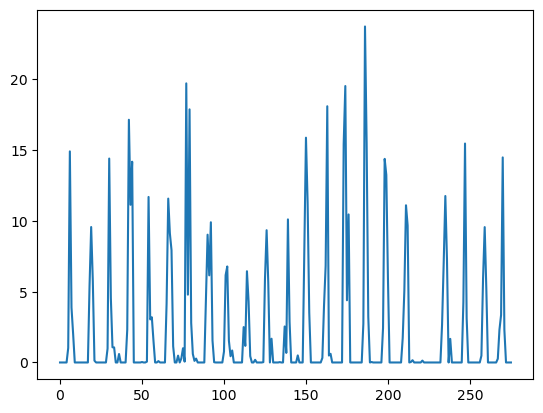

In [88]:

import matplotlib.pyplot as plt
plt.plot(df1)

In [89]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
df1 = scaler.fit_transform(np.array(df1).reshape(-1,1))

In [90]:
print(df1)


[[0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [4.31199311e-02]
 [6.28245209e-01]
 [1.63517738e-01]
 [8.48353042e-02]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [2.27266549e-01]
 [4.03153459e-01]
 [2.42988537e-01]
 [5.43699878e-03]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [4.14344615e-02]
 [6.06904988e-01]
 [1.91790132e-01]
 [4.52267682e-02]
 [4.48552399e-02]
 [0.00000000e+00]
 [0.00000000e+00]
 [2.52820443e-02]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [9.75635603e-02]
 [7.22381745e-01]
 [4.69348919e-01]
 [5.97498981e-01]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.35924969e-03]
 [0.00000000e+00]
 [0.00000000e+00]
 [2.52820443e-03]
 [4.92636616e-01]
 [1.281772

In [91]:
training_size = int(len(df1)*0.65)
test_size = len(df1)-training_size
train_data,test_data = df1[0:training_size,:],df1[training_size:len(df1),:1]

In [92]:
training_size,test_size


(179, 97)

In [93]:
import numpy as np
def create_dataset(dataset,time_step=1):
    dataX, dataY = [] , []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step),0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX),np.array(dataY)

In [94]:
time_step = 70
X_train , y_train = create_dataset(train_data ,time_step)
X_test , y_test = create_dataset(test_data , time_step)

In [95]:
print(X_train.shape)


(108, 70)


In [96]:
print(X_train.shape) , print(y_train.shape)


(108, 70)
(108,)


(None, None)

In [97]:
print(X_test.shape) , print(y_test.shape)


(26, 70)
(26,)


(None, None)

In [98]:
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] ,1)

In [99]:
X_train


array([[[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.38412396],
        [0.33428481],
        [0.04838929]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.33428481],
        [0.04838929],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.04838929],
        [0.        ],
        [0.        ]],

       ...,

       [[0.03574827],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.65031036],
        [0.82275384]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.65031036],
        [0.82275384],
        [0.18512981]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.82275384],
        [0.18512981],
        [0.44060985]]])

In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [101]:
model = Sequential()
model.add(LSTM(50,activation = 'tanh',return_sequences=True,input_shape=(70,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer = 'adam')

In [102]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 70, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 70, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
lstm_model = model.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 50,batch_size = 12,validation_split=0.2,verbose=1)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 238ms/step - loss: 0.0410 - val_loss: 0.0245
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0399 - val_loss: 0.0217
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0383 - val_loss: 0.0225
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0378 - val_loss: 0.0209
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0372 - val_loss: 0.0222
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0365 - val_loss: 0.0206
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0357 - val_loss: 0.0189
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0323 - val_loss: 0.0169
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0307 - val_loss: 0.0170
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0289 - val_loss: 0.0137
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0274 - val_loss: 0.0142
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0295 - val_loss: 0.014

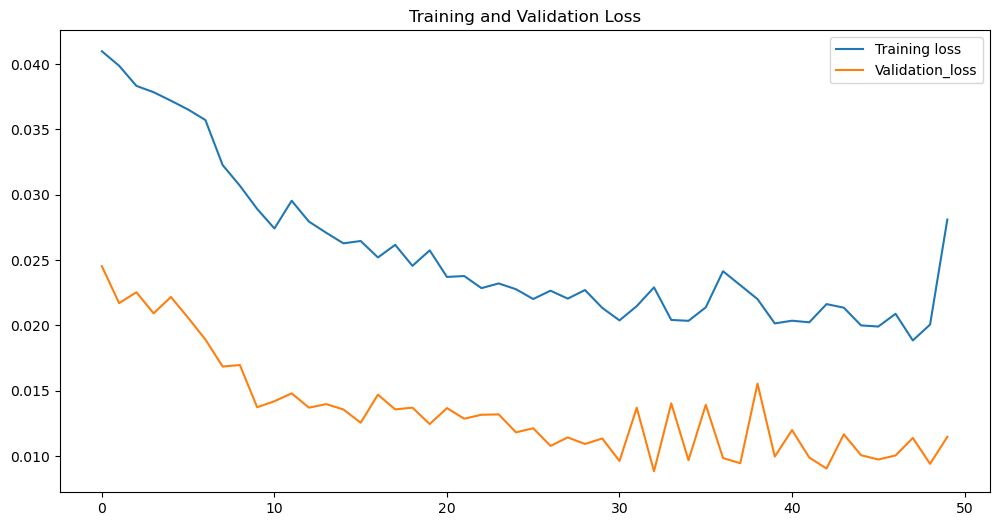

In [104]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lstm_model.history['loss'],label = 'Training loss')
ax.plot(lstm_model.history['val_loss'],label = 'Validation_loss')
ax.set_title('Training and Validation Loss')
ax.legend()


In [105]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


In [106]:
true_predictions = scaler.inverse_transform(test_predict)


In [107]:
# Create a date range for the next 26 months
future_dates = pd.date_range(start='2013-12-31', periods=26, freq='MS')
future_dates

DatetimeIndex(['2014-01-01', '2014-02-01', '2014-03-01', '2014-04-01',
               '2014-05-01', '2014-06-01', '2014-07-01', '2014-08-01',
               '2014-09-01', '2014-10-01', '2014-11-01', '2014-12-01',
               '2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01',
               '2016-01-01', '2016-02-01'],
              dtype='datetime64[ns]', freq='MS')

In [108]:
true_predictions


array([[2.1289132 ],
       [1.109988  ],
       [0.7539247 ],
       [0.6674548 ],
       [0.6101426 ],
       [0.6259715 ],
       [0.99871653],
       [2.033383  ],
       [3.615406  ],
       [4.93203   ],
       [5.033239  ],
       [3.7589633 ],
       [2.105095  ],
       [1.063439  ],
       [0.67599803],
       [0.57348776],
       [0.52709085],
       [0.5795322 ],
       [0.99581414],
       [2.041446  ],
       [3.561807  ],
       [4.6731415 ],
       [4.4815025 ],
       [3.068316  ],
       [1.7345662 ],
       [1.0385134 ]], dtype=float32)

In [109]:
future_values = pd.DataFrame({'RF': true_predictions.flatten()}, index=future_dates)
future_values

,RF
2014-01-01,2.128913
2014-02-01,1.109988
2014-03-01,0.753925
2014-04-01,0.667455
2014-05-01,0.610143
2014-06-01,0.625971
2014-07-01,0.998717
2014-08-01,2.033383
2014-09-01,3.615406
2014-10-01,4.932030


In [110]:
# Replace negative values with zero
future_values = future_values.clip(lower=0)

In [111]:
all_data = pd.concat([df2,future_values],axis=0)

#   Forecasted Plot


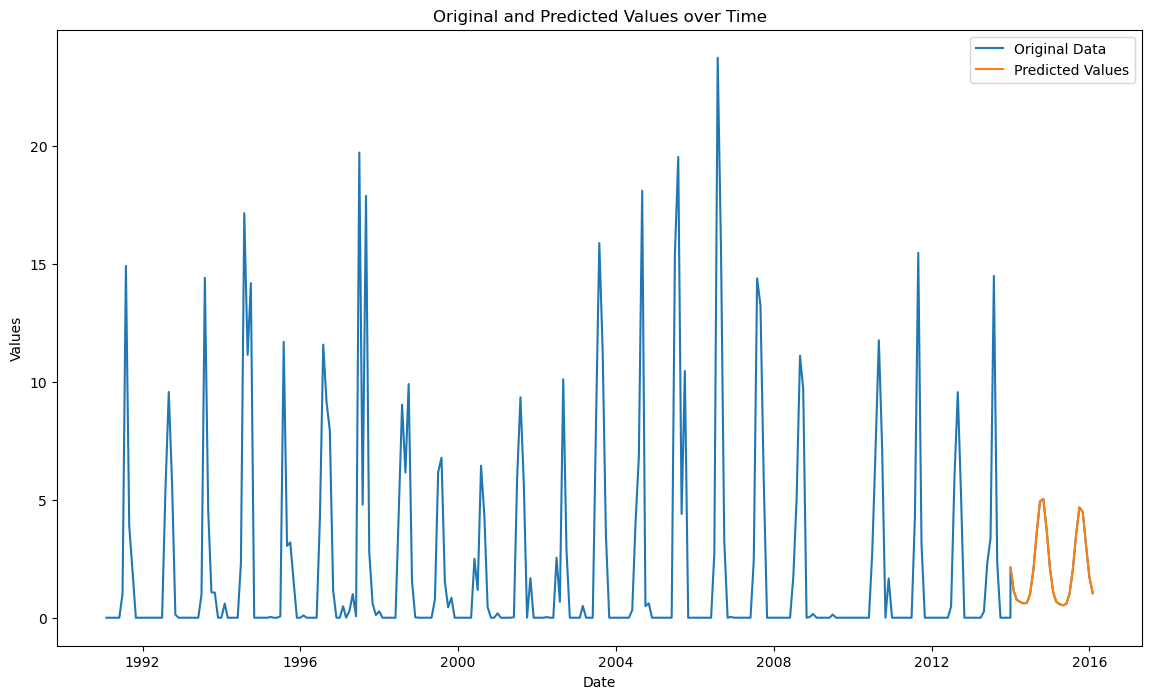

In [112]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the original data
ax.plot(all_data.index, all_data['RF'], label='Original Data')

# Plot the predicted values
ax.plot(future_values.index, future_values['RF'], label='Predicted Values')

# Set the axis labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Values')
ax.set_title('Original and Predicted Values over Time')

# Add a legend
ax.legend()

# Show the plot
plt.show()


#   Performance Evaluation Metrics


In [113]:
## calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error

# calculate MAE
mae = mean_absolute_error(y_test, test_predict)
print('MAE:', mae)

# calculate MSE
mse = mean_squared_error(y_test, test_predict)
print('MSE:', mse)

### Test Data RMSE
RMSE = math.sqrt(mean_squared_error(y_test,test_predict))
print('RMSE:',RMSE)

MAE: 0.07059163143909306
MSE: 0.011477322899523109
RMSE: 0.1071322682459543


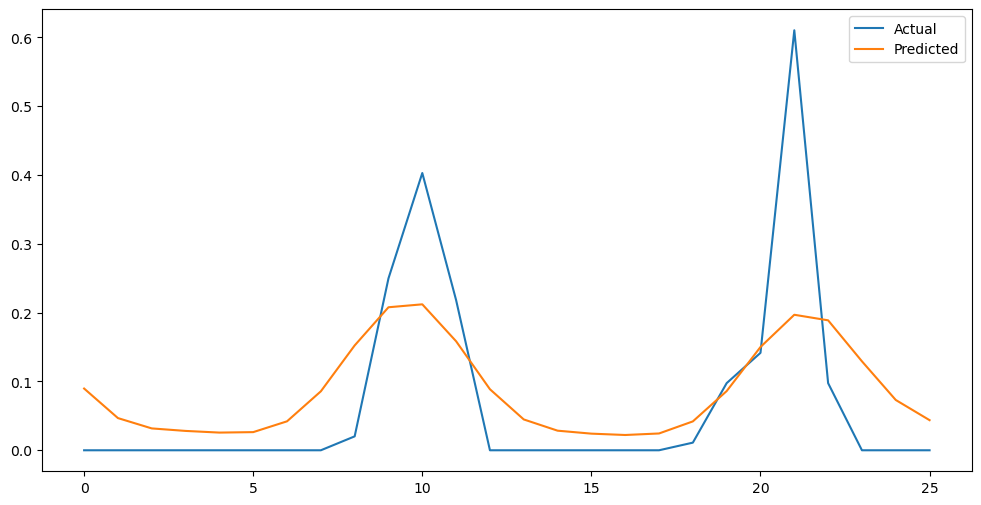

In [114]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_test, label='Actual')
ax.plot(test_predict, label='Predicted')
ax.legend()
plt.show()

#   Trying with different hyperparameters


In [115]:
model_l1 = Sequential()
model_l1.add(LSTM(50,activation = 'tanh',return_sequences=True,input_shape=(70,1)))
model_l1.add(LSTM(50,return_sequences=True))
model_l1.add(LSTM(50))
model_l1.add(Dense(1))
model_l1.compile(loss='mean_squared_error',optimizer = 'adam')

In [116]:
# Train the model
lstm_model_l1 = model_l1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=12, verbose=1)

# Evaluate the model on the test dataset
mse = model_l1.evaluate(X_test, y_test)
print('Mean Squared Error:', mse)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 260ms/step - loss: 0.0419 - val_loss: 0.0249
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0396 - val_loss: 0.0214
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.0387 - val_loss: 0.0220
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0380 - val_loss: 0.0213
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0373 - val_loss: 0.0216
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.0370 - val_loss: 0.0211
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0359 - val_loss: 0.0204
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0340 - val_loss: 0.0198
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0318 - val_loss: 0.0172
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.0295 - val_loss: 0.0145
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0287 - val_loss: 0.0133
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0281 - val_loss: 0.015

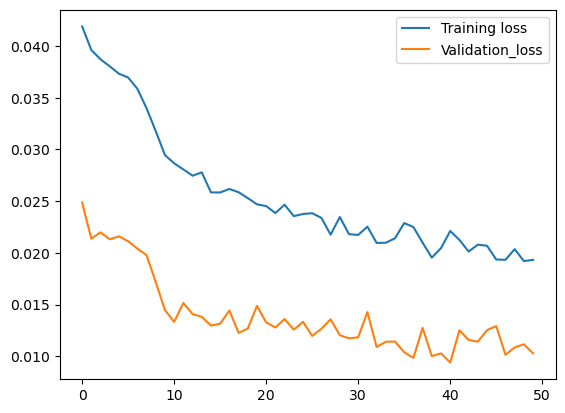

In [117]:
plt.plot(lstm_model_l1.history['loss'],label = 'Training loss')
plt.plot(lstm_model_l1.history['val_loss'],label = 'Validation_loss')
plt.legend()

In [118]:
test


,RF
Date,
2007-02-28,0.000000
2007-03-31,0.000000
2007-04-30,0.000000
2007-05-31,0.000000
2007-06-30,2.426667
...,...
2013-08-31,2.315404
2013-09-30,0.000000
2013-10-31,0.000000


#   Double Exponential Model

In [119]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [120]:
# Fit the model with double exponential smoothing
expo_model = ExponentialSmoothing(train, trend='add', seasonal=None).fit()

In [121]:
expo_model.summary()


Dep. Variable:,RF,No. Observations:,193
Model:,ExponentialSmoothing,SSE,4620.664
Optimized:,True,AIC,620.891
Trend:,Additive,BIC,633.942
Seasonal:,None,AICC,621.343
Seasonal Periods:,None,Date:,"Wed, 29 Apr 2026"
Box-Cox:,False,Time:,09:12:07
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.6424457,alpha,True
smoothing_trend,2.4922e-08,beta,True


In [122]:
# Make predictions for the test set
expo_predictions = expo_model.predict(start=test.index[0], end=test.index[-1])

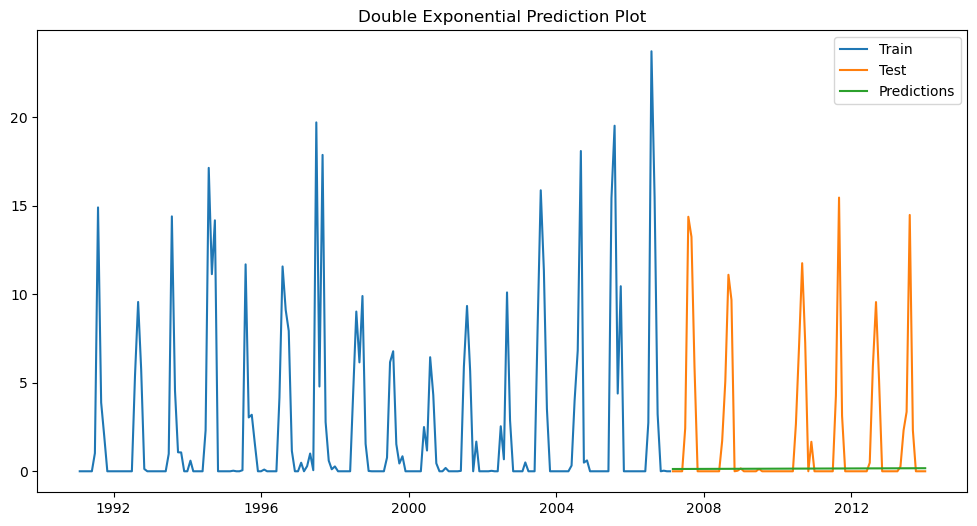

In [123]:
# Plot the actual and predicted values
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train.index, train.values, label='Train')
ax.plot(test.index, test.values, label='Test')
ax.plot(expo_predictions.index, expo_predictions.values, label='Predictions')
ax.set_title('Double Exponential Prediction Plot')
ax.legend()
plt.show()

In [124]:
## Calculate the accuracy metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, expo_predictions)
mse = mean_squared_error(test, expo_predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - expo_predictions) / test)) * 100

# Print the accuracy metrics
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')


MAE: 1.99
MSE: 18.38
RMSE: 4.29
MAPE: nan%


#   Triple Exponential Smoothing (Holt Winters Methods)

In [125]:
train


,RF
Date,
1991-01-31,0.000000
1991-02-28,0.000000
1991-03-31,0.000000
1991-04-30,0.000000
1991-05-31,0.000000
...,...
2006-09-30,3.233333
2006-10-31,0.000000
2006-11-30,0.033333


In [126]:
# Fit the model with triple exponential smoothing
texpo_model = ExponentialSmoothing(train, seasonal_periods=12, seasonal='add').fit()

In [127]:
texpo_model.summary()


Dep. Variable:,RF,No. Observations:,193
Model:,ExponentialSmoothing,SSE,1709.866
Optimized:,True,AIC,449.026
Trend:,None,BIC,494.703
Seasonal:,Additive,AICC,452.117
Seasonal Periods:,12,Date:,"Wed, 29 Apr 2026"
Box-Cox:,False,Time:,09:12:08
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.4902e-08,alpha,True
smoothing_seasonal,1.9048e-13,gamma,True


In [128]:
# Make predictions for the test set
texpo_predictions = texpo_model.predict(start=test.index[0], end=test.index[-1])

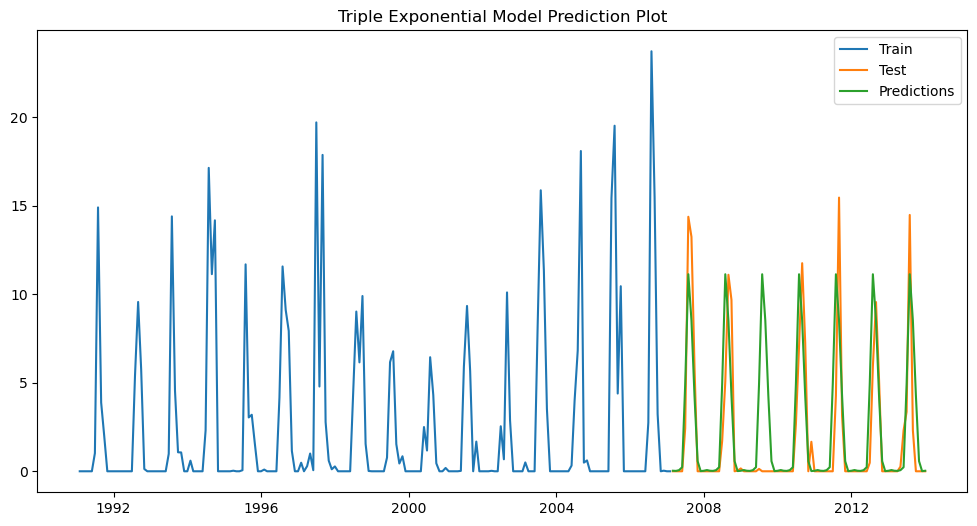

In [129]:
# Plot the actual and predicted values

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train.index, train.values, label='Train')
ax.plot(test.index, test.values, label='Test')
ax.plot(texpo_predictions.index, texpo_predictions.values, label='Predictions')
ax.set_title('Triple Exponential Model Prediction Plot')
ax.legend()
plt.show()

In [130]:
## Calculate the accuracy metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, texpo_predictions)
mse = mean_squared_error(test, texpo_predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - texpo_predictions) / test)) * 100

# Print the accuracy metrics
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')


MAE: 1.55
MSE: 7.88
RMSE: 2.81
MAPE: nan%


#   Define the GRU network architecture

In [131]:
gru_model = Sequential()
gru_model.add(GRU(50, input_shape=(70, 1)))  # 64 units, input sequence of length 10, and one feature per time step
gru_model.add(Dense(1, activation='relu'))
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [132]:
# Compile the model with mean squared error loss and Adam optimizer
gru_model.compile(loss='mse', optimizer='adam')

In [133]:
# Train the model
gru_model_fit = gru_model.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 50,batch_size = 12,validation_split=0.2,verbose=1)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0495 - val_loss: 0.0263
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0495 - val_loss: 0.0263


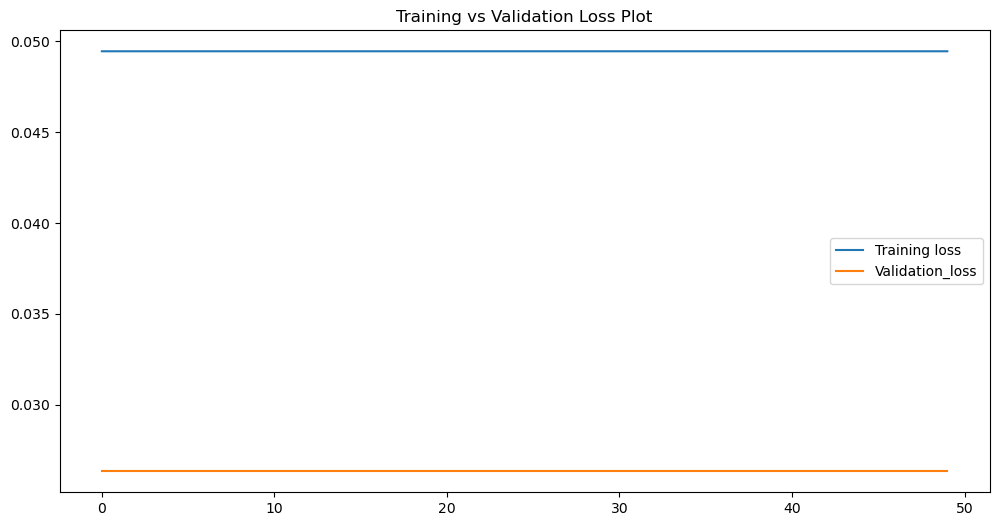

In [134]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(gru_model_fit.history['loss'], label='Training loss')
ax.plot(gru_model_fit.history['val_loss'], label='Validation_loss')
ax.set_title('Training vs Validation Loss Plot')
ax.legend()
plt.show()  # This actually displays the plot


In [135]:
gtrain_predict = gru_model.predict(X_train)
gtest_predict = gru_model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


In [136]:
gru_true_predicted = scaler.inverse_transform(gtest_predict)

In [137]:
gru_future_values = pd.DataFrame({'RF': gru_true_predicted.flatten()}, index=future_dates)
gru_future_values


,RF
2014-01-01,0.0
2014-02-01,0.0
2014-03-01,0.0
2014-04-01,0.0
2014-05-01,0.0
2014-06-01,0.0
2014-07-01,0.0
2014-08-01,0.0
2014-09-01,0.0
2014-10-01,0.0


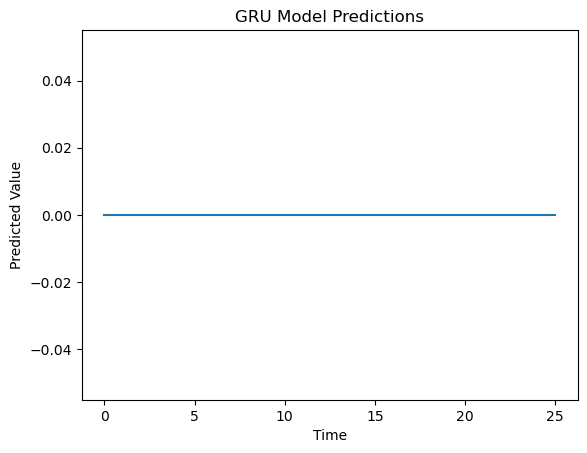

In [138]:
# Plot the predicted values
plt.plot(gru_true_predicted)
plt.xlabel('Time')
plt.ylabel('Predicted Value')
plt.title('GRU Model Predictions')
plt.show()


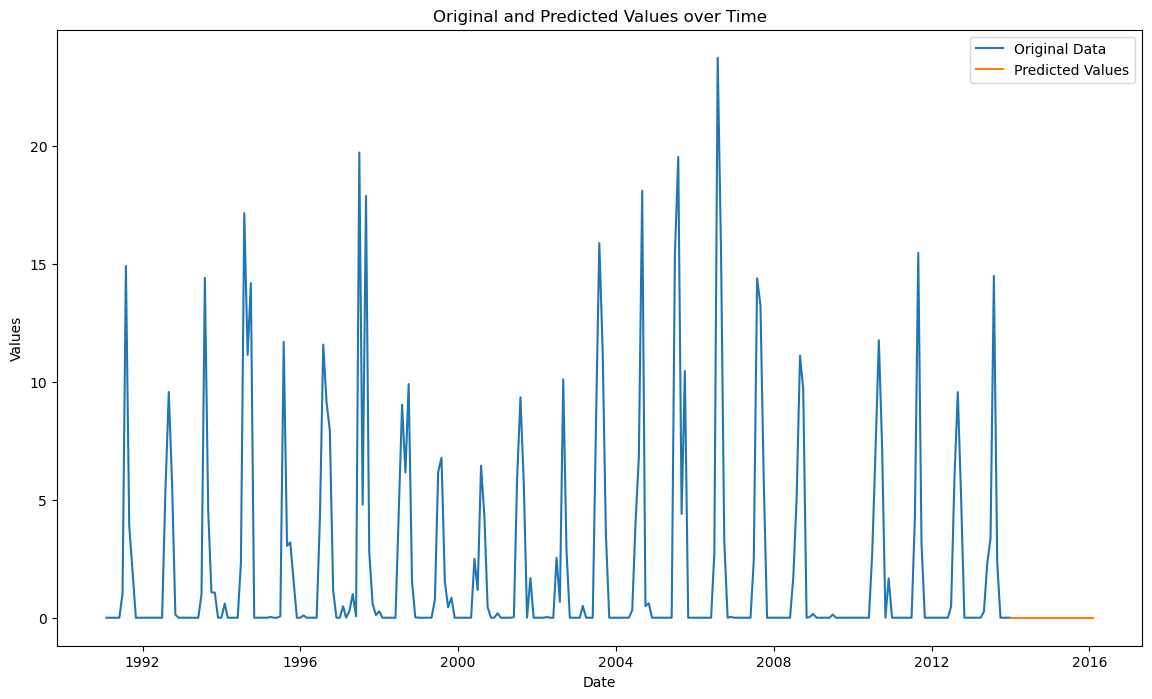

In [139]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the original data
ax.plot(df2.index, df2['RF'], label='Original Data')

# Plot the predicted values
ax.plot(gru_future_values.index, gru_future_values['RF'], label='Predicted Values')

# Set the axis labels and title
ax.set_xlabel('Date')
ax.set_ylabel('Values')
ax.set_title('Original and Predicted Values over Time')

# Add a legend
ax.legend()

# Show the plot
plt.show()

In [140]:
# Evaluate the model on the test dataset
gru_mse = gru_model.evaluate(X_test,y_test)
print('Mean Squared Error:', gru_mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0263
Mean Squared Error: 0.02632279135286808


#   Forecasted Plot of GRU model

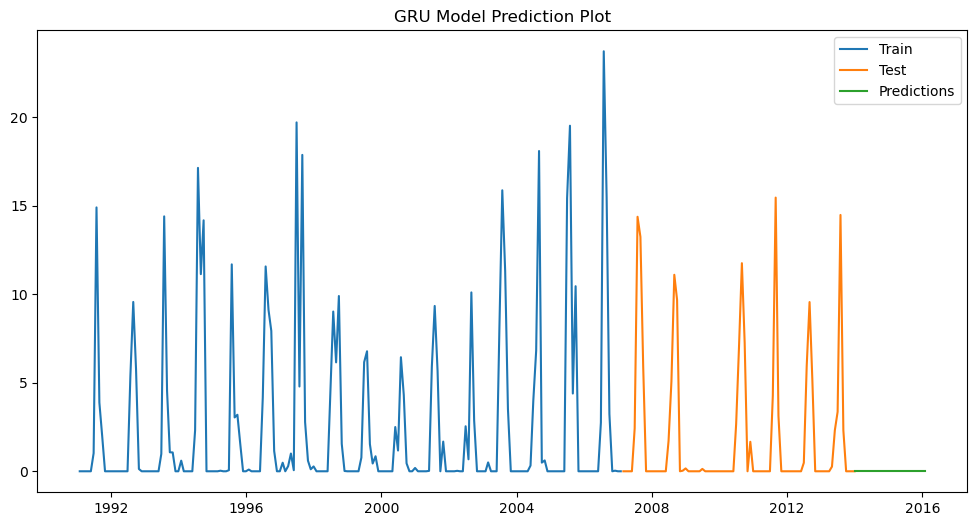

In [141]:

# Plot the actual and predicted values

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train.index, train.values, label='Train')
ax.plot(test.index, test.values, label='Test')
ax.plot(gru_future_values.index, gru_future_values.values, label='Predictions')
ax.set_title('GRU Model Prediction Plot')
ax.legend()
plt.show()

In [142]:
gru_future_values


,RF
2014-01-01,0.0
2014-02-01,0.0
2014-03-01,0.0
2014-04-01,0.0
2014-05-01,0.0
2014-06-01,0.0
2014-07-01,0.0
2014-08-01,0.0
2014-09-01,0.0
2014-10-01,0.0


#   Performance of Evaluation Metrics


In [143]:
## calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error

# calculate MAE
mae = mean_absolute_error(y_test, gtest_predict)
print('MAE:', mae)

# calculate MSE
mse = mean_squared_error(y_test, gtest_predict)
print('MSE:', mse)

### Test Data RMSE
RMSE = math.sqrt(mean_squared_error(y_test,gtest_predict))
print('RMSE:',RMSE)

MAE: 0.07112195724797032
MSE: 0.026322790541426715
RMSE: 0.16224299843576215


#   Conclusion